In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_absolute_error as MAE
import matplotlib.pyplot as plt

In [2]:
# Data preparation
df = pd.read_csv('../spreadsheets/prestige.csv')
df.head()

,job,education,income,women,prestige,census,type
0,gov.administrators,13.11,12351,11.16,68.8,1113,prof
1,general.managers,12.26,25879,4.02,69.1,1130,prof
2,accountants,12.77,9271,15.70,63.4,1171,prof
3,purchasing.officers,11.42,8865,9.11,56.8,1175,prof
4,chemists,14.62,8403,11.68,73.5,2111,prof


In [4]:
X = df[['education','women', 'prestige']]
y = df['income']

In [ ]:
# Separate training and validation data
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.3, random_state =123)

,education,women,prestige
91,6.60,0.52,36.2
33,11.44,8.13,54.1
70,7.64,17.26,25.2
85,10.10,0.78,50.3
79,8.43,13.62,35.9
...,...,...,...
83,6.38,90.67,28.2
17,14.15,77.10,58.1
98,7.93,3.59,25.1
92,7.81,2.46,29.9


In [ ]:
# Create a model
model = LR()
model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Check the regression equation
model.coef_
model.intercept_

np.float64(-291.5527059562255)

In [11]:
# Model Evaluation : MAE
pred = model.predict (X_test)
MAE(y_test , pred)

1787.3166863311678

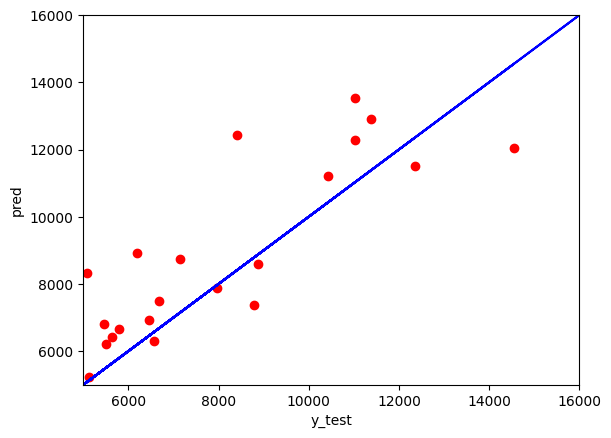

In [12]:
plt.scatter (y_test , pred , color="red",)
plt.xlim ([5000,16000])
plt.ylim ([5000,16000])
plt.xlabel('y_test')
plt.ylabel('pred')
plt.plot(y_test,y_test , color='blue') # draw diagonal line
plt.show()

In [17]:
# Model Utilization
job = pd.DataFrame([[12, 10, 80]], columns= X_test.columns)
job
pred = model.predict(job)
pred

array([13007.9197067])